In [391]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
from sklearn.tree import plot_tree
import re
import pickle
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset

The first step involves loading the dataset. To load this, Pandas will be used.

In [201]:
df = pd.read_csv("car_prices.csv")

Let's check if the data is loaded successfully and what are the features of this data.

In [202]:
df.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [203]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

This shows, that this dataset has eleven features that give us information about the various properties of the car. This is a Regression problem where we will predict the price of each car. 

# Data Pre Processing

Let's inspect the data to checkout the missing values, outliers or mis classification of data.

In [204]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB
None


In [205]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [206]:
df.dtypes

brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

## Checking for NULL Values

In [207]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

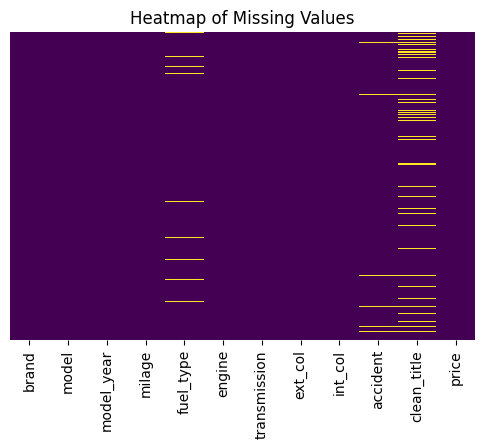

In [208]:
# Plotting a heatmap to visualize null values
plt.figure(figsize=(6, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap of Missing Values')
plt.show()

This indicates that there are null values in the fuel_type, accident, and clean title columns. Let's calculate the percentage of the clean values each column have.

In [209]:
df.isnull().sum() / len(df)*100

brand            0.000000
model            0.000000
model_year       0.000000
milage           0.000000
fuel_type        4.240459
engine           0.000000
transmission     0.000000
ext_col          0.000000
int_col          0.000000
accident         2.818658
clean_title     14.866550
price            0.000000
dtype: float64

There are 4% null values in fuel_type and 2% in accident. So, it feels safe to drop null rows from these columns. However, there are 14% null values in clean_title which has to be addressed.

In [210]:
df['clean_title'].value_counts()

clean_title
Yes    3413
Name: count, dtype: int64

In [211]:
df['clean_title']

0       Yes
1       Yes
2       NaN
3       Yes
4       NaN
       ... 
4004    Yes
4005    Yes
4006    NaN
4007    Yes
4008    Yes
Name: clean_title, Length: 4009, dtype: object

The clean title column has got only "Yes" in 86% of its columns. The rest of values are Null. It makes sense that they can be "No". But, since we do not have much insights of the data. It feels safe to drop this column.

In [212]:
df1 = df.drop(["clean_title"], axis = 1)
df1.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999"


Let's move to **fuel_type** and **accident** column to gather insights and handle null values.

In [213]:
df1["fuel_type"].value_counts()

fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In the column **fuel type**, - and not supported does not make any sense. There are 170 null values, 45 - values and 2 not supported. Replacing these 217 values with the mode, which is Gasoline will be helpful.

In [214]:
# Replacing null, - and not supported values with Mode
mode_fueltype = df1['fuel_type'].mode()[0]
df1['fuel_type'].fillna(mode_fueltype, inplace=True)
df1['fuel_type'].replace('not supported', mode_fueltype, inplace=True)
df1['fuel_type'].replace('–', mode_fueltype, inplace=True)
df1["fuel_type"].value_counts()

fuel_type
Gasoline          3526
Hybrid             194
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
Name: count, dtype: int64

Let's move to accident column to analyze it.

In [215]:
df1["accident"].value_counts()

accident
None reported                             2910
At least 1 accident or damage reported     986
Name: count, dtype: int64

In [216]:
df2 = df1.dropna()
len(df2), len(df1)

(3896, 4009)

All the null values have been dealt in our dataframe.

In [217]:
df2.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
price           0
dtype: int64

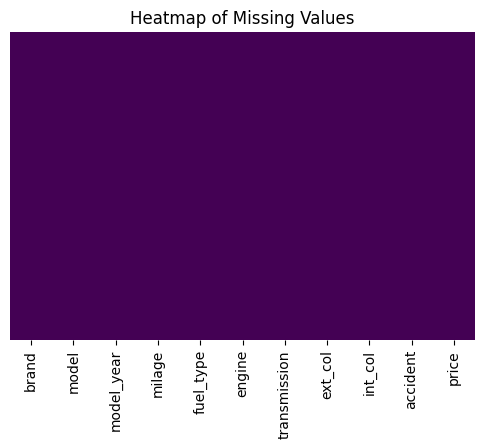

In [218]:
# Plotting a heatmap to visualize null values
plt.figure(figsize=(6, 4))
sns.heatmap(df2.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap of Missing Values')
plt.show()

## Checking for duplicate rows

In [219]:
df2[df2.duplicated()]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price


This indicates that our dataset does not have any duplicate rows.

## Checking the Data Types

In [220]:
df2.dtypes

brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
price           object
dtype: object

We will have to analyze each column separately to understand its key features and to check out if the data type is justified.

In [221]:
df2.nunique()

brand             57
model           1862
model_year        34
milage          2747
fuel_type          5
engine          1130
transmission      62
ext_col          315
int_col          152
accident           2
price           1527
dtype: int64

### Brand

In [222]:
df2['brand'].value_counts()

brand
Ford             372
BMW              367
Mercedes-Benz    310
Chevrolet        285
Toyota           196
Audi             194
Porsche          186
Lexus            161
Jeep             138
Land             126
Nissan           114
Cadillac         104
RAM               90
Dodge             89
GMC               88
Tesla             87
Kia               75
Hyundai           68
Subaru            63
Acura             63
Mazda             62
Honda             60
Volkswagen        59
INFINITI          56
Lincoln           50
Jaguar            46
Volvo             37
Maserati          33
MINI              32
Bentley           31
Buick             30
Chrysler          27
Lamborghini       26
Mitsubishi        20
Genesis           19
Hummer            16
Alfa              16
Pontiac           15
Rivian            15
Ferrari           12
Rolls-Royce       10
Aston              8
Scion              6
McLaren            6
Saturn             5
FIAT               5
Mercury            3
Lotus  

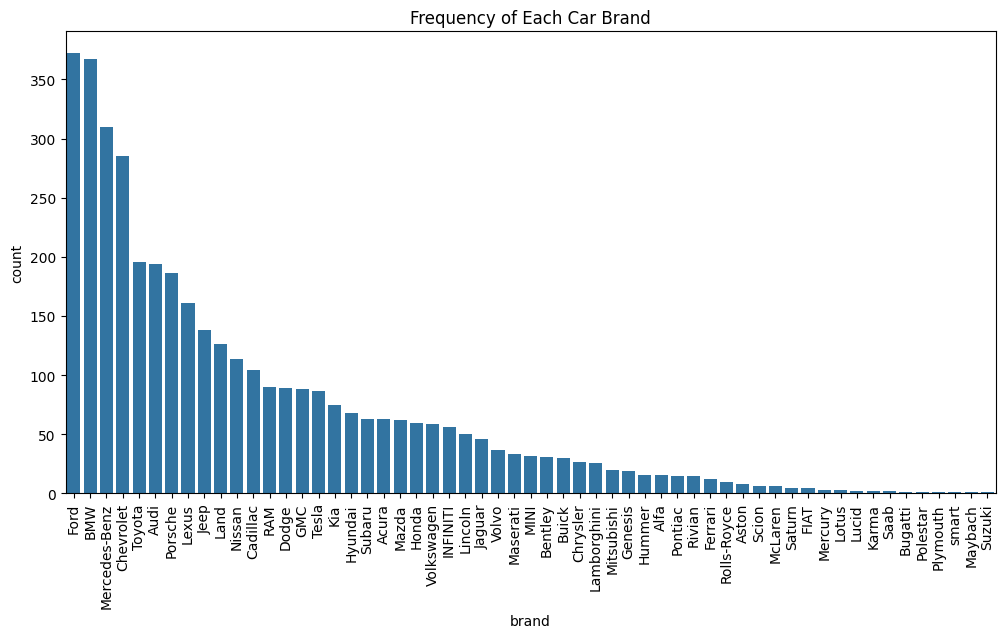

In [223]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df2, x='brand', order=df2['brand'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Frequency of Each Car Brand')
plt.show()

Most of the cars are **Ford** an **BMW**. 

Since, there are 57 unique values in this column and model and this column is related, it would make more sense to do target Encoding then One Hot Encoding.

### Model

In [224]:
df2['model'].value_counts()

model
M3 Base                29
F-150 XLT              23
Corvette Base          22
1500 Laramie           18
Wrangler Sport         17
                       ..
Canyon Denali           1
Elantra HEV Limited     1
Grand Caravan SE        1
Q8 3.0T Premium         1
Optima SX Turbo         1
Name: count, Length: 1862, dtype: int64

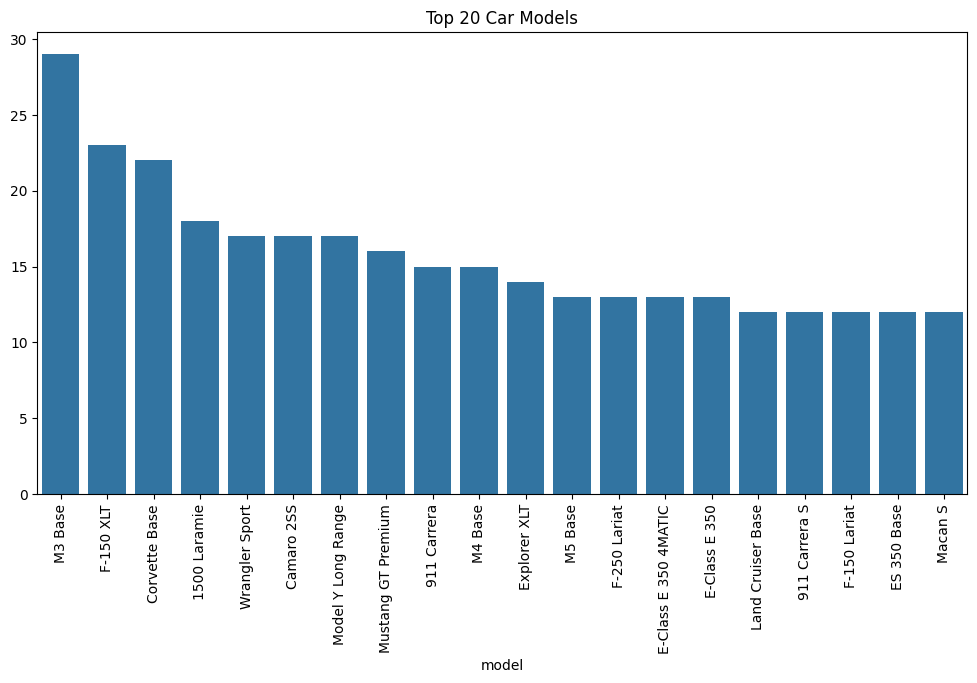

In [225]:
top_models = df2['model'].value_counts().nlargest(20)  # Adjust the number as needed
plt.figure(figsize=(12, 6))
sns.barplot(x=top_models.index, y=top_models.values)
plt.xticks(rotation=90)
plt.title('Top 20 Car Models')
plt.show()

This plot shows the top 20 models out of the 1862 models.

### Model Year

In [226]:
df2["model_year"].dtype

dtype('int64')

In [227]:
df2["model_year"].value_counts()

model_year
2022    347
2021    335
2018    307
2020    307
2019    292
2016    264
2017    256
2015    224
2023    216
2014    177
2013    151
2012    136
2011    121
2008    110
2010     99
2007     96
2009     71
2005     70
2006     63
2004     58
2003     45
2001     32
2002     32
2000     17
1999     15
1998     11
1993      9
1997      8
1994      7
2024      6
1996      6
1995      6
1992      1
1974      1
Name: count, dtype: int64

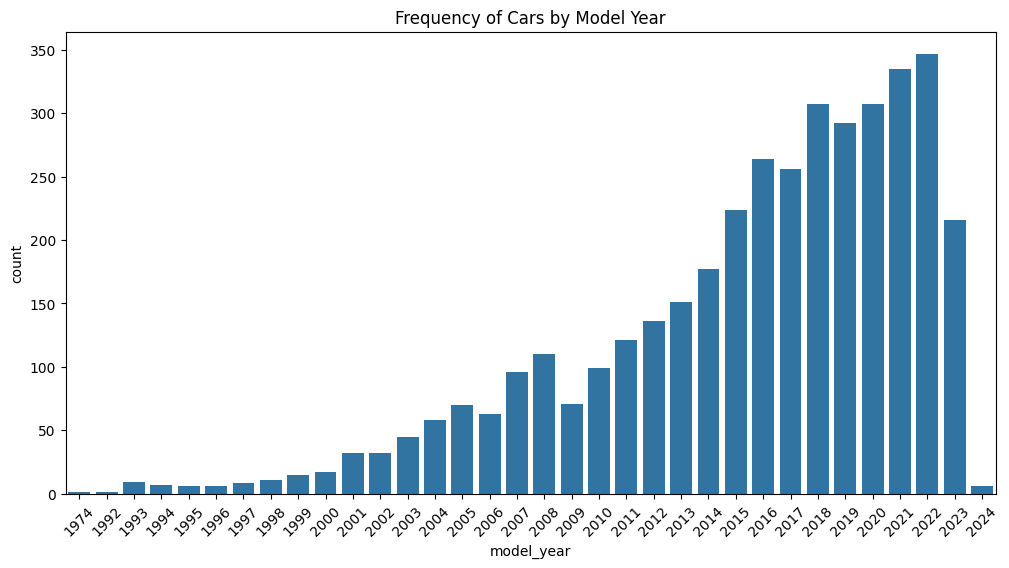

In [228]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df2, x='model_year', order=sorted(df2['model_year'].unique()))
plt.xticks(rotation=45)
plt.title('Frequency of Cars by Model Year')
plt.show()


Most of the models in our dataset are the latest model. However, not much models of the current year are added.

### Milage

In [229]:
df2['milage'].value_counts()

milage
110,000 mi.    16
45,000 mi.     15
55,000 mi.     12
54,000 mi.     12
40,000 mi.     12
               ..
2,823 mi.       1
104,700 mi.     1
11,650 mi.      1
96,541 mi.      1
23,442 mi.      1
Name: count, Length: 2747, dtype: int64

Milage has to be a numerical column. Re-Formatting this column to convert to numerical one.

In [230]:
df2['milage'] = df2['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '').astype(int)
df2.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300"
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005"
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999"


In [231]:
df2['milage'].dtype

dtype('int64')

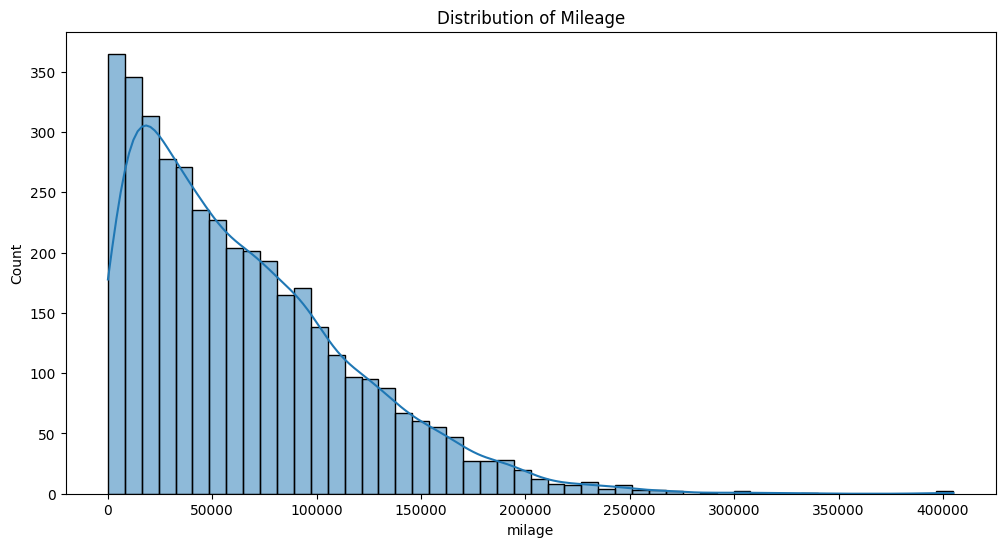

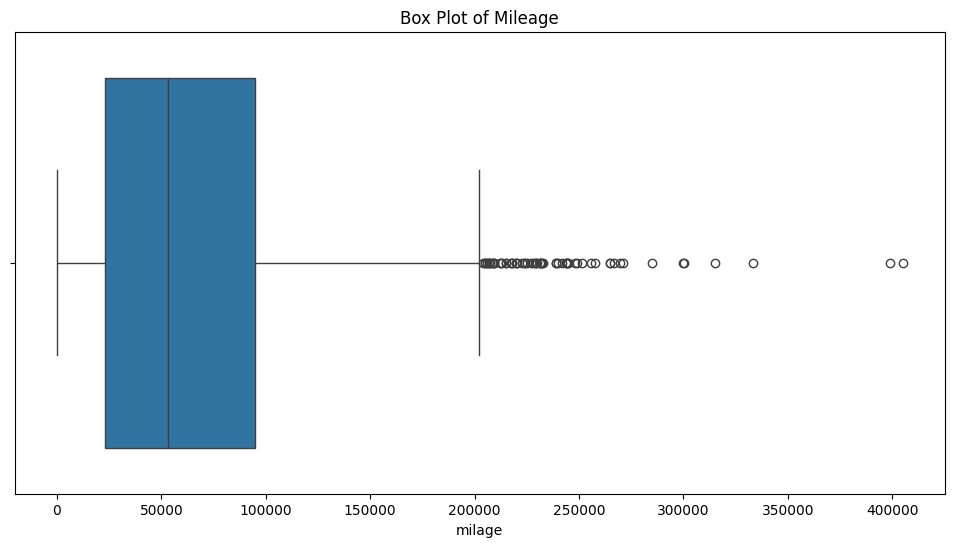

In [232]:
plt.figure(figsize=(12, 6))
sns.histplot(df2['milage'], bins=50, kde=True)
plt.title('Distribution of Mileage')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df2['milage'])
plt.title('Box Plot of Mileage')
plt.show()

Most of the values are in the range of 0 to 50000 and then the values begin to increase.

The values above 200000 is considered as outliers in this dataset.

In [233]:
### Fuel Type
df2['fuel_type'].value_counts()

fuel_type
Gasoline          3430
Hybrid             190
E85 Flex Fuel      133
Diesel             110
Plug-In Hybrid      33
Name: count, dtype: int64

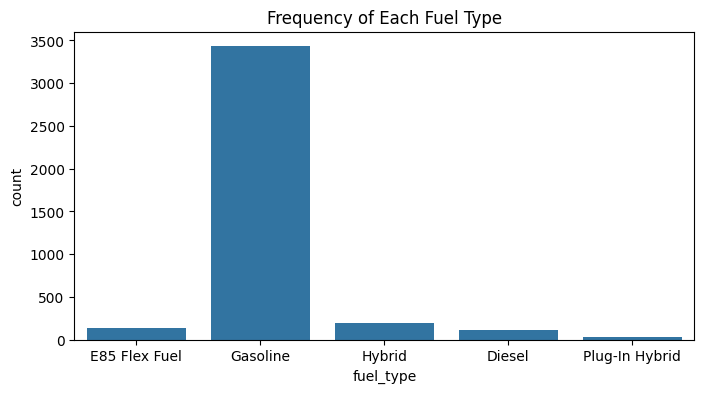

In [234]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df2, x='fuel_type')
plt.title('Frequency of Each Fuel Type')
plt.show()

Most of the Cars uses gasoline. There is only a little fraction of the cars that use other type of fuels.

### Engine

In [235]:
df2['engine'].value_counts()

engine
2.0L I4 16V GDI DOHC Turbo                               52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             46
–                                                        44
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel    42
                                                         ..
300.0HP 3.4L Flat 6 Cylinder Engine Gasoline Fuel         1
305.0HP 6.8L 10 Cylinder Engine Gasoline Fuel             1
562.0HP 5.2L 10 Cylinder Engine Gasoline Fuel             1
245.0HP 5.9L Straight 6 Cylinder Engine Diesel Fuel       1
572.0HP 3.8L Flat 6 Cylinder Engine Gasoline Fuel         1
Name: count, Length: 1130, dtype: int64

In [236]:
df2['engine'].unique()

array(['300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability',
       '3.8L V6 24V GDI DOHC', '3.5 Liter DOHC', ...,
       '169.0HP 2.5L 4 Cylinder Engine Flex Fuel Capability',
       '136.0HP 1.8L 4 Cylinder Engine Gasoline Fuel',
       '270.0HP 2.0L 4 Cylinder Engine Gasoline Fuel'], dtype=object)

From the given information, following 3 columns can be extracted from the Engine data Horsepower, Liters and Cylinders.

In [237]:
# Function to extract features
def extract_features(engine_str):
    hp = 0
    liters = 0
    cylinders = 0
    engine_type = "None"
    
    # Extract horsepower (HP)
    hp_match = re.search(r'(\d+\.\d+)HP', engine_str)
    if hp_match:
        hp = float(hp_match.group(1))
    
    # Extract engine displacement (Liters)
    liters_match = re.search(r'(\d+\.\d+)L|\b(\d+\.\d+)\b Liter', engine_str)
    if liters_match:
        liters = float(liters_match.group(1) if liters_match.group(1) else liters_match.group(2))
    
    # Extract cylinder count
    cylinders_match = re.search(r'(\d+) Cylinder|V(\d+)', engine_str)
    if cylinders_match:
        cylinders = int(cylinders_match.group(1) if cylinders_match.group(1) else cylinders_match.group(2))
    
    engine_type_match = re.search(r'V\d+|I\d+|Flat \d+|Electric Motor|V-\d+', engine_str, re.IGNORECASE)
    if engine_type_match:
        engine_type = engine_type_match.group(0)
    else:
        # Handle more generic or unusual cases
        if 'Electric' in engine_str:
            engine_type = 'Electric Motor'
        elif 'Turbo' in engine_str:
            engine_type = 'Turbo'
    
    return hp, liters, cylinders, engine_type

# Apply the function to extract features
df3 = df2.copy()
df3[['horsepower', 'displacement_liters', 'cylinders', 'engine_type']] = df3['engine'].apply(lambda x: pd.Series(extract_features(x)))

# Display the result
df3.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,horsepower,displacement_liters,cylinders,engine_type
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300",300.0,3.7,6,V6
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005",0.0,3.8,6,V6
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598",0.0,3.5,0,None
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500",354.0,3.5,6,V6
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999",0.0,2.0,0,I4


In [238]:
df3.dtypes

brand                   object
model                   object
model_year               int64
milage                   int64
fuel_type               object
engine                  object
transmission            object
ext_col                 object
int_col                 object
accident                object
price                   object
horsepower             float64
displacement_liters    float64
cylinders                int64
engine_type             object
dtype: object

In [239]:
df3["engine_type"].value_counts()

engine_type
None              2076
V6                1031
Electric Motor     291
I4                 151
V8                 128
Flat 6              85
Turbo               73
I3                  14
V12                  9
V-6                  9
I6                   9
V-8                  8
V10                  6
V-10                 4
V-12                 2
Name: count, dtype: int64

Now, we have extracted meaningful information from the **Engine** column. It is safe to drop it.

In [240]:
df3.drop(['engine'], axis=1, inplace=True)

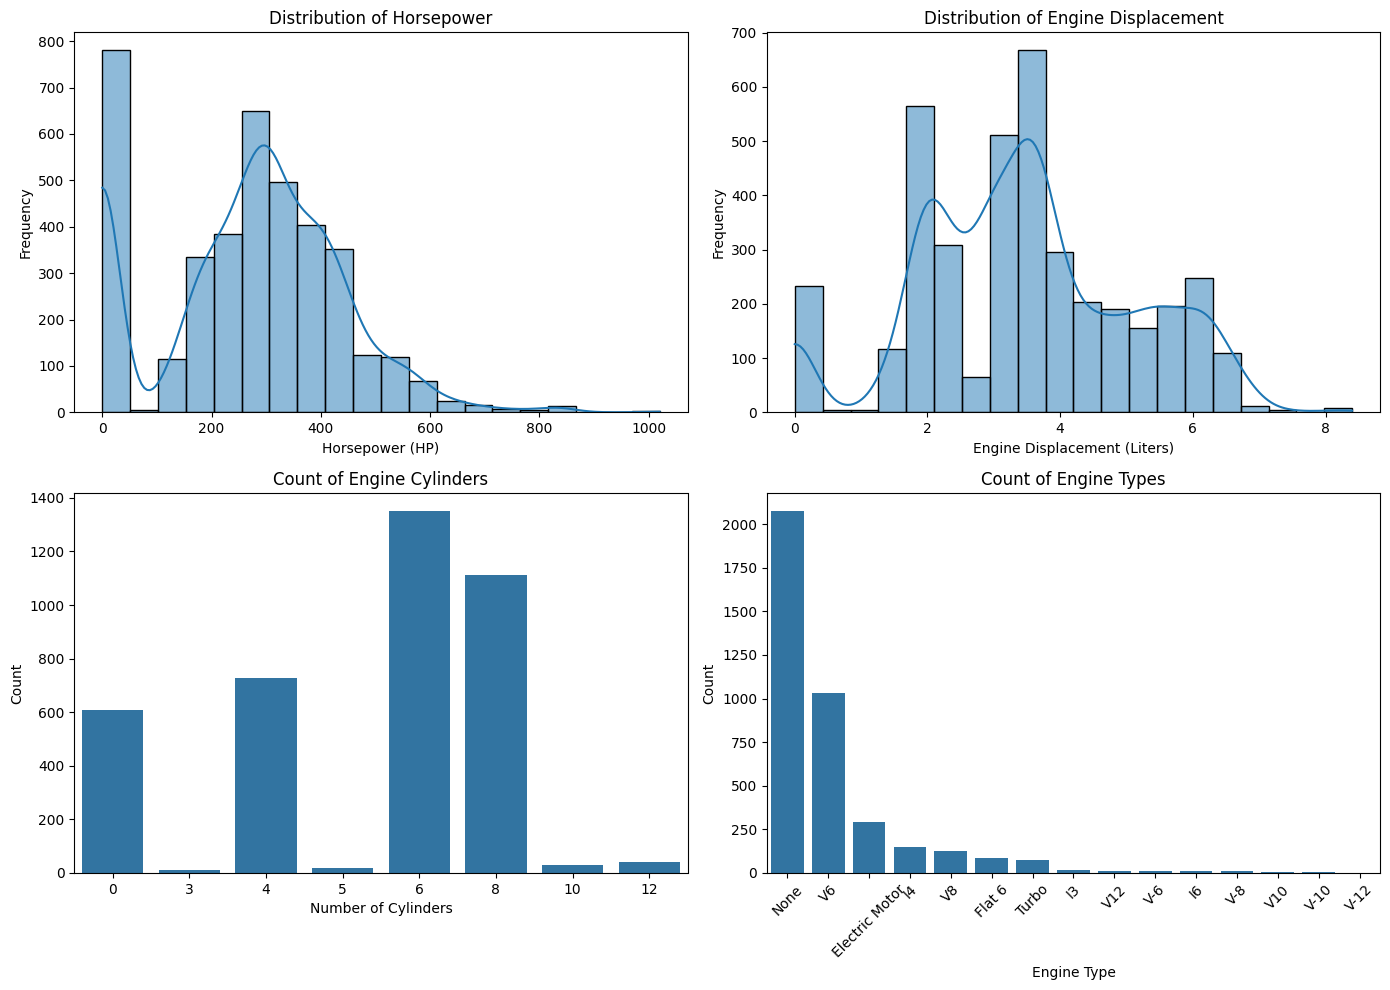

In [241]:
## Visualizing the new_columns made
# Plotting
plt.figure(figsize=(14, 10))

# 1. Histogram for Horsepower
plt.subplot(2, 2, 1)
sns.histplot(df3['horsepower'], bins=20, kde=True)
plt.title('Distribution of Horsepower')
plt.xlabel('Horsepower (HP)')
plt.ylabel('Frequency')

# 2. Histogram for Engine Displacement (Liters)
plt.subplot(2, 2, 2)
sns.histplot(df3['displacement_liters'], bins=20, kde=True)
plt.title('Distribution of Engine Displacement')
plt.xlabel('Engine Displacement (Liters)')
plt.ylabel('Frequency')

# 3. Bar Plot for Cylinders
plt.subplot(2, 2, 3)
sns.countplot(data=df3, x='cylinders')
plt.title('Count of Engine Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Count')

# 4. Bar Plot for Engine Type
plt.subplot(2, 2, 4)
sns.countplot(data=df3, x='engine_type', order=df3['engine_type'].value_counts().index)
plt.title('Count of Engine Types')
plt.xlabel('Engine Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Insights into the Data Shows us that unknown Horsepowers i.e. 0 are more in number. Similarly, there are some in No. of Cylinders and Engine Displacement too. In case of Engine Type, The Unknown engines exceed any of the rest.

### Transmission

In [242]:
df3["transmission"].value_counts().index

Index(['A/T', '8-Speed A/T', 'Transmission w/Dual Shift Mode', '6-Speed A/T',
       '6-Speed M/T', 'Automatic', '7-Speed A/T', '8-Speed Automatic',
       '10-Speed A/T', '5-Speed A/T', '9-Speed A/T', '4-Speed A/T',
       '6-Speed Automatic', '1-Speed A/T', 'CVT Transmission', '5-Speed M/T',
       '10-Speed Automatic', '9-Speed Automatic', 'M/T', 'Automatic CVT',
       '7-Speed Automatic with Auto-Shift', '1-Speed Automatic',
       '5-Speed Automatic', '8-Speed Automatic with Auto-Shift', '7-Speed M/T',
       '6-Speed Manual', 'Transmission Overdrive Switch', '7-Speed Automatic',
       '6-Speed Automatic with Auto-Shift', '4-Speed Automatic', '–',
       'Automatic, 8-Spd', 'Variable', '2', '2-Speed A/T', 'Manual, 6-Spd',
       'Manual', 'F', 'Automatic, 9-Spd 9G-Tronic', '7-Speed Manual',
       '8-SPEED AT', 'CVT-F',
       'Automatic, 8-Spd M STEPTRONIC w/Drivelogic, Sport & Manual Modes',
       'Automatic, 8-Spd Sport w/Sport & Manual Modes',
       'Auto, 6-Spd w/CmdShft'

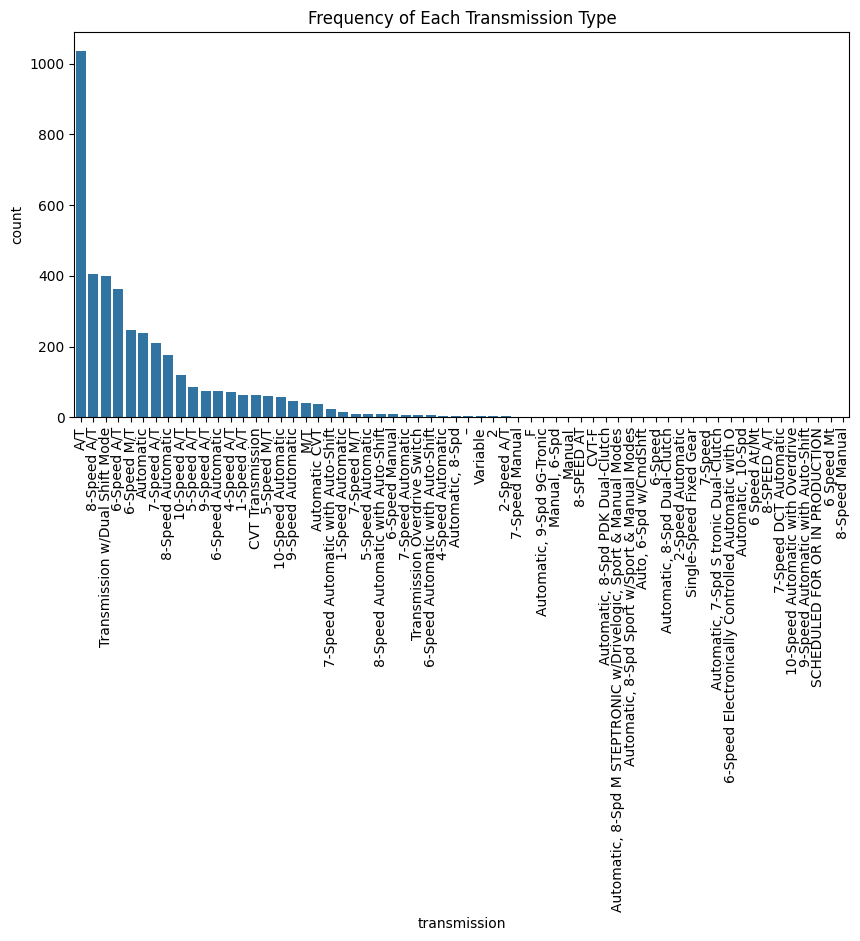

In [243]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='transmission', order=df['transmission'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Frequency of Each Transmission Type')
plt.show()

Most of the transmissions have extremely less counts. They can be put in a new category "Others".

In [244]:
value_counts = df3["transmission"].value_counts()

In [245]:
# Identify categories with count of 1
rare_categories = value_counts[value_counts < 10].index

# Replace rare categories with 'Others'
df3['transmission'] = df3['transmission'].apply(lambda x: 'Others' if x in rare_categories else x)

# Verify the changes
print(df3['transmission'].value_counts())

transmission
A/T                                  1015
8-Speed A/T                           391
Transmission w/Dual Shift Mode        389
6-Speed A/T                           354
6-Speed M/T                           238
Automatic                             230
7-Speed A/T                           201
8-Speed Automatic                     168
10-Speed A/T                          115
Others                                107
5-Speed A/T                            84
9-Speed A/T                            73
4-Speed A/T                            72
6-Speed Automatic                      65
1-Speed A/T                            63
CVT Transmission                       62
5-Speed M/T                            57
10-Speed Automatic                     54
9-Speed Automatic                      46
M/T                                    38
Automatic CVT                          36
7-Speed Automatic with Auto-Shift      24
1-Speed Automatic                      14
Name: count, dtype: i

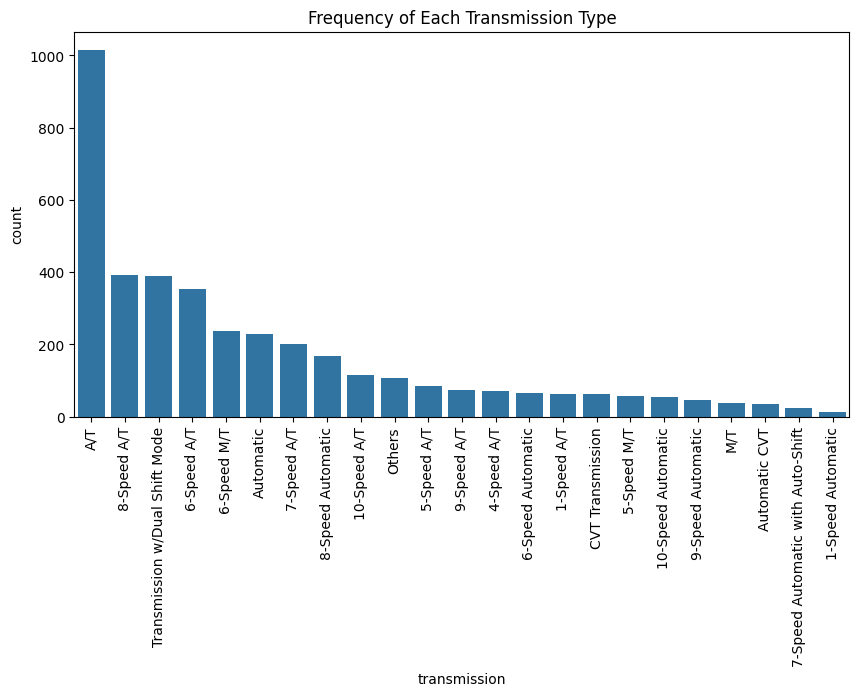

In [246]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df3, x='transmission', order=df3['transmission'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Frequency of Each Transmission Type')
plt.show()

### Accident

In [247]:
df3['accident'].value_counts()

accident
None reported                             2910
At least 1 accident or damage reported     986
Name: count, dtype: int64

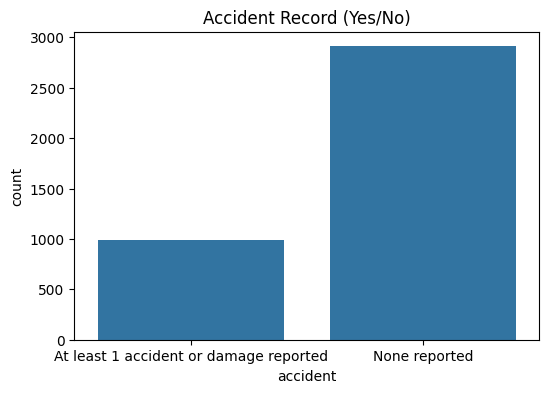

In [248]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='accident')
plt.title('Accident Record (Yes/No)')
plt.show()

Accidents have only 2 columns which can be encoded easily.

### Int_col -- Interior Color & Ext_col -- Exterior Color

In [249]:
df3['int_col'].value_counts()

int_col
Black                   1971
Beige                    522
Gray                     460
Brown                    152
–                        128
                        ... 
Gray w/Blue Bolsters       1
Very Light Cashmere        1
Black / Gray               1
Deep Chestnut              1
Black / Graphite           1
Name: count, Length: 152, dtype: int64

In [250]:
df3['ext_col'].value_counts()

ext_col
Black                      879
White                      798
Gray                       485
Silver                     361
Blue                       340
                          ... 
Carpathian Grey              1
Nightfall Gray Metallic      1
Lunar Rock                   1
Quartzite Grey Metallic      1
C / C                        1
Name: count, Length: 315, dtype: int64

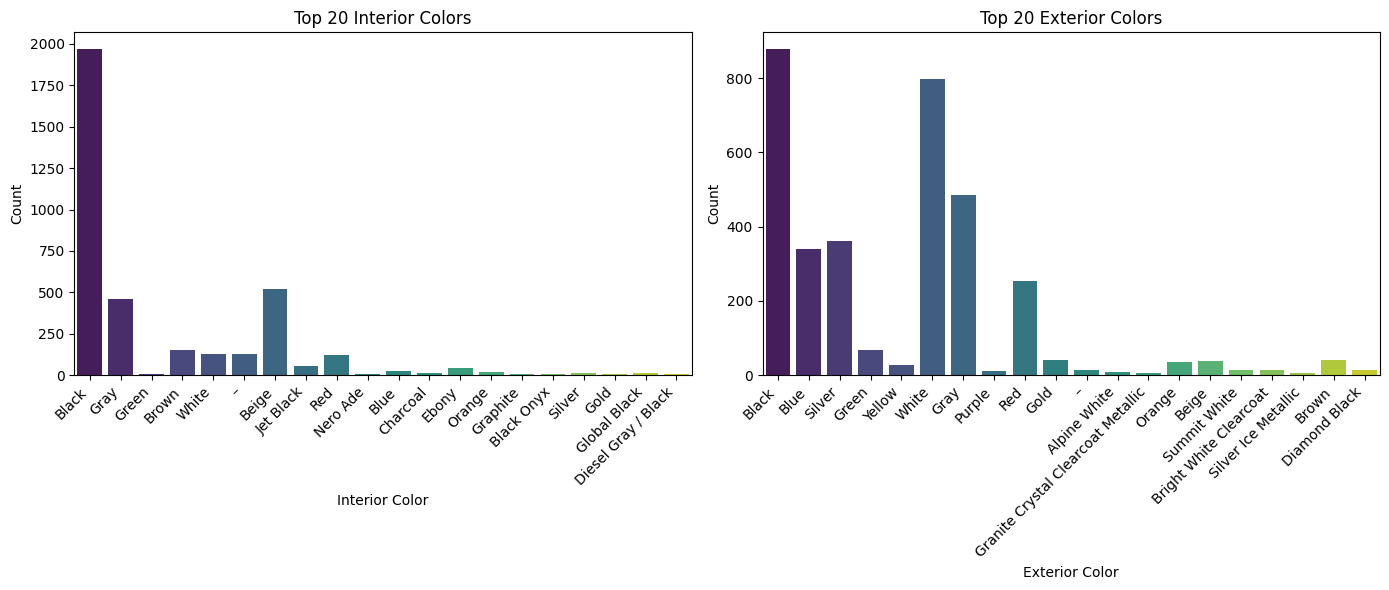

In [251]:
# Get the top 20 most frequent colors for interior and exterior
top_int_colors = df3['int_col'].value_counts().nlargest(20).index
top_ext_colors = df3['ext_col'].value_counts().nlargest(20).index

# Filter the DataFrame to only include these top 20 colors
df_int_filtered = df3[df3['int_col'].isin(top_int_colors)]
df_ext_filtered = df3[df3['ext_col'].isin(top_ext_colors)]

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Plot for top 20 interior colors
sns.countplot(data=df_int_filtered, x='int_col', ax=axes[0], palette='viridis')
axes[0].set_title('Top 20 Interior Colors')
axes[0].set_xlabel('Interior Color')
axes[0].set_ylabel('Count')

# Plot for top 20 exterior colors
sns.countplot(data=df_ext_filtered, x='ext_col', ax=axes[1], palette='viridis')
axes[1].set_title('Top 20 Exterior Colors')
axes[1].set_xlabel('Exterior Color')
axes[1].set_ylabel('Count')

# Rotate x labels for better readability
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

These graphs shows the top 20 most used colors in interior and exterior which are not absolutely the same. Let's analyze the if there is a co relation between these columns or not.

In [252]:
# Create a contingency table
contingency_table = pd.crosstab(df3['int_col'], df3['ext_col'])

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramer's V
n = contingency_table.sum().sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
k_corr = k - (k - 1)**2 / (n - 1)
r_corr = r - (r - 1)**2 / (n - 1)
cramers_v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.6446


There is 64% Co-Relation between both these columns. Let's try to categorize the rare colors in other category.

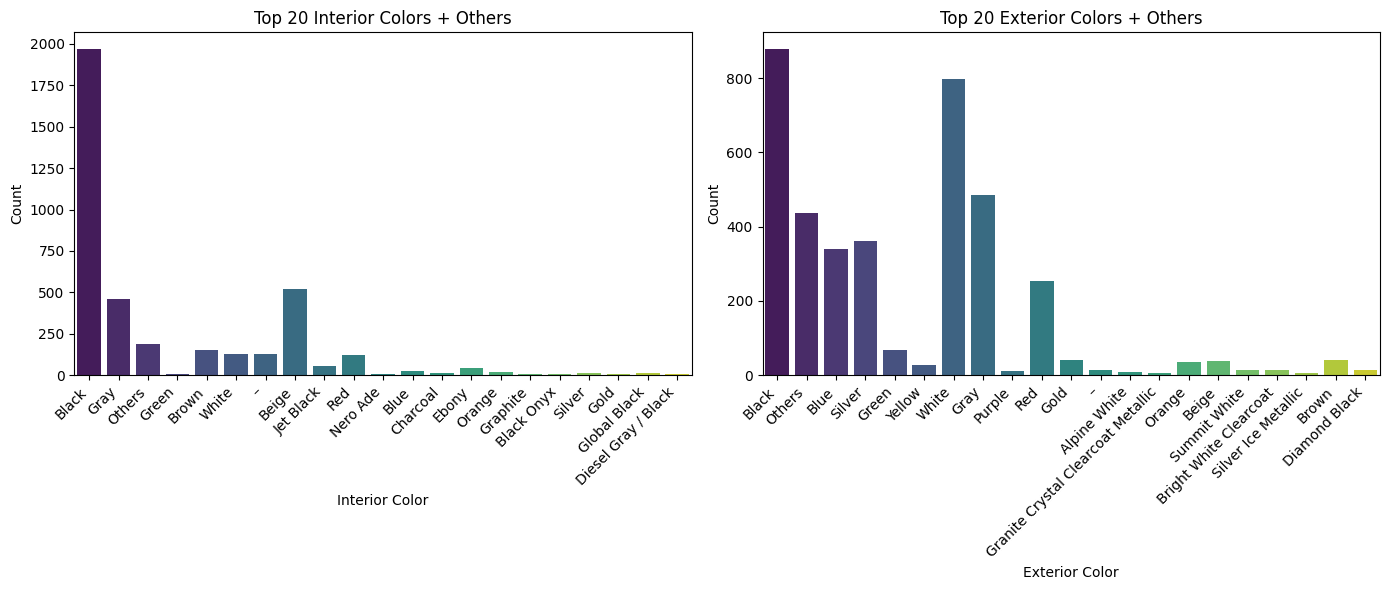

In [253]:
# Get top 20 colors for interior and exterior
top_int_colors = df3['int_col'].value_counts().nlargest(20).index
top_ext_colors = df3['ext_col'].value_counts().nlargest(20).index

# Replace less frequent colors with 'Others'
df3['int_col'] = df3['int_col'].apply(lambda x: x if x in top_int_colors else 'Others')
df3['ext_col'] = df3['ext_col'].apply(lambda x: x if x in top_ext_colors else 'Others')

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Plot for interior colors
sns.countplot(data=df3, x='int_col', ax=axes[0], palette='viridis')
axes[0].set_title('Top 20 Interior Colors + Others')
axes[0].set_xlabel('Interior Color')
axes[0].set_ylabel('Count')

# Plot for exterior colors
sns.countplot(data=df3, x='ext_col', ax=axes[1], palette='viridis')
axes[1].set_title('Top 20 Exterior Colors + Others')
axes[1].set_xlabel('Exterior Color')
axes[1].set_ylabel('Count')

# Rotate x labels for better readability
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

Let's Check the Co Relation Again.

In [254]:
# Create a contingency table
contingency_table = pd.crosstab(df3['int_col'], df3['ext_col'])

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramer's V
n = contingency_table.sum().sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
k_corr = k - (k - 1)**2 / (n - 1)
r_corr = r - (r - 1)**2 / (n - 1)
cramers_v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.2197


The Co-Relation has fallen down to 22% which means that both of these columns are equally important.

### Price -- The Target Column

In [255]:
df3['price'].dtype

dtype('O')

The datatype is **Object** because of the $ sign which needs to be eliminated.

In [256]:
df4 = df3.copy()
df4['price'] = df3['price'].replace({'\$': '', ',': ''}, regex=True)
df4['price'] = pd.to_numeric(df4['price'])
df4.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,price,horsepower,displacement_liters,cylinders,engine_type
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,6-Speed A/T,Black,Black,At least 1 accident or damage reported,10300,300.0,3.7,6,V6
1,Hyundai,Palisade SEL,2021,34742,Gasoline,8-Speed Automatic,Others,Gray,At least 1 accident or damage reported,38005,0.0,3.8,6,V6
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Automatic,Blue,Black,None reported,54598,0.0,3.5,0,None
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,7-Speed A/T,Black,Black,None reported,15500,354.0,3.5,6,V6
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,8-Speed Automatic,Others,Black,None reported,34999,0.0,2.0,0,I4


In [257]:
df4['price'].dtype

dtype('int64')

Now, our Price column is converted into integer data type.

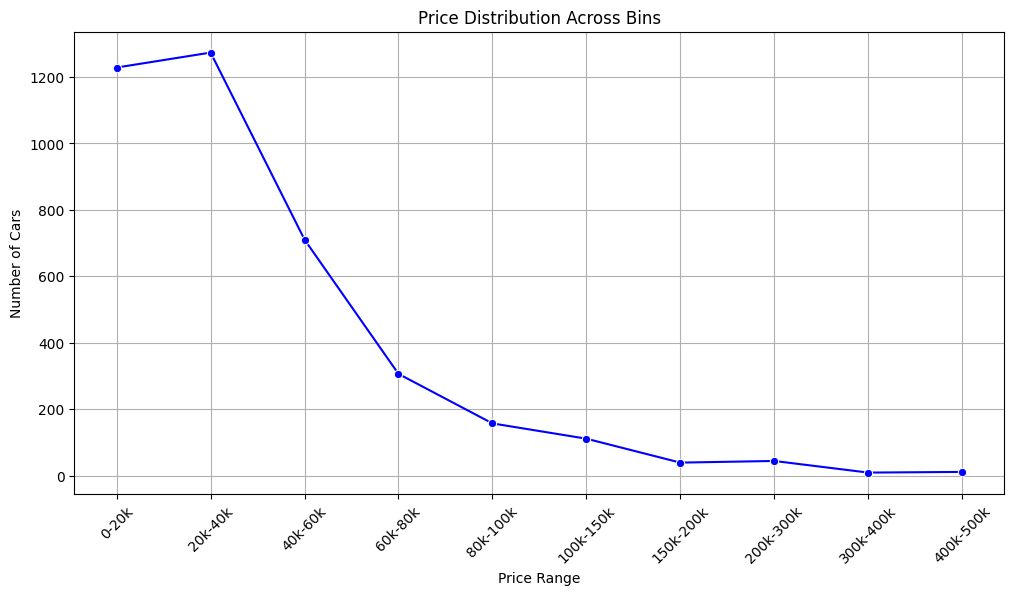

In [258]:
df_demo = df4.copy()
# Define price bins and labels
bins = [0, 20000, 40000, 60000, 80000, 100000, 150000, 200000, 300000, 400000, 500000]
labels = ['0-20k', '20k-40k', '40k-60k', '60k-80k', '80k-100k', '100k-150k', '150k-200k', '200k-300k', '300k-400k', '400k-500k']

# Create a new column for price bins
df_demo['price_bin'] = pd.cut(df4['price'], bins=bins, labels=labels)

# Count the number of entries in each bin
price_bin_counts = df_demo['price_bin'].value_counts().sort_index()

# Plot the price ranges using a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=price_bin_counts.index, y=price_bin_counts.values, marker='o', color='blue')
plt.title('Price Distribution Across Bins')
plt.xlabel('Price Range')
plt.ylabel('Number of Cars')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

This shows that most of our values lies in the range of 20k - 40k dollars.

Now, we have analyzed all the columns and gathered useful insights from the data. Let's do some furthur analysis of numerical columns.

## Numerical Column Analysis 

In [259]:
df5 = df4.copy()
# df5 will be used to store any changes made in this analysis.

In [260]:
numerical_cols = df4.select_dtypes(include='number').columns
numerical_cols

df_numerical = df4[numerical_cols]

df_numerical.head()

,model_year,milage,price,horsepower,displacement_liters,cylinders
0,2013,51000,10300,300.0,3.7,6
1,2021,34742,38005,0.0,3.8,6
2,2022,22372,54598,0.0,3.5,0
3,2015,88900,15500,354.0,3.5,6
4,2021,9835,34999,0.0,2.0,0


### Handling OutLiers

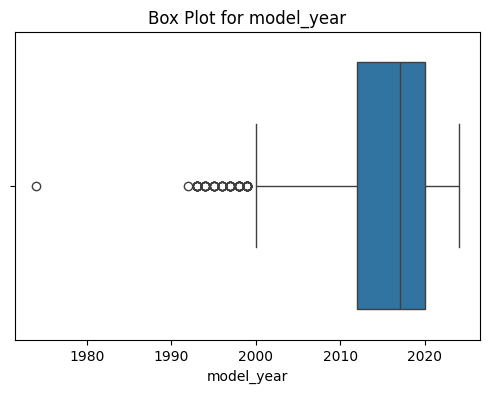

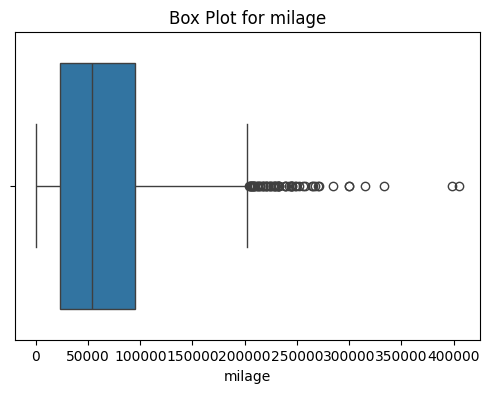

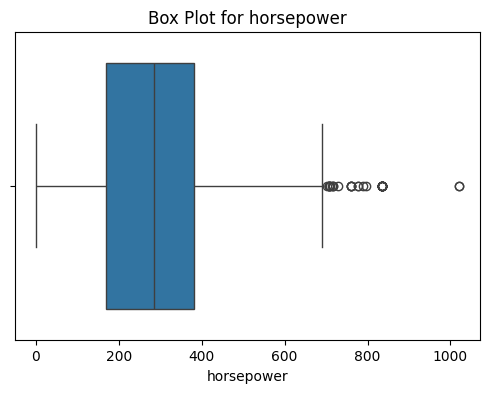

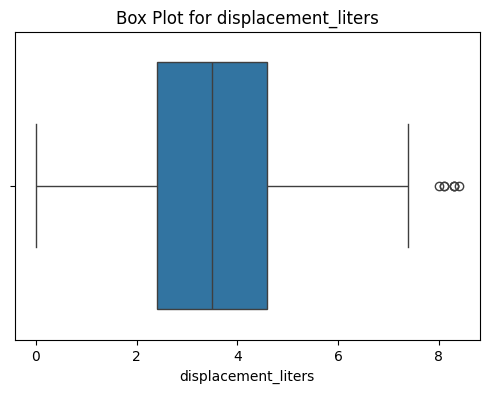

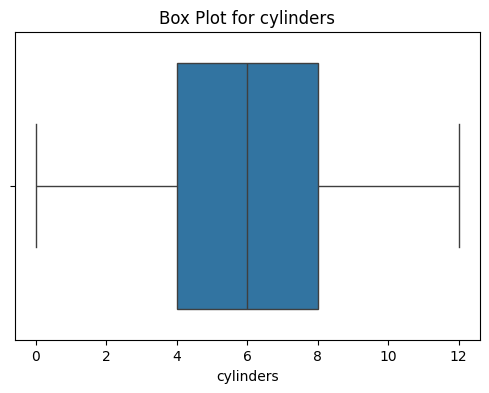

In [261]:
for column in df_numerical.drop(['price'], axis = 1).columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df5[column])
    plt.title(f'Box Plot for {column}')
    plt.show()

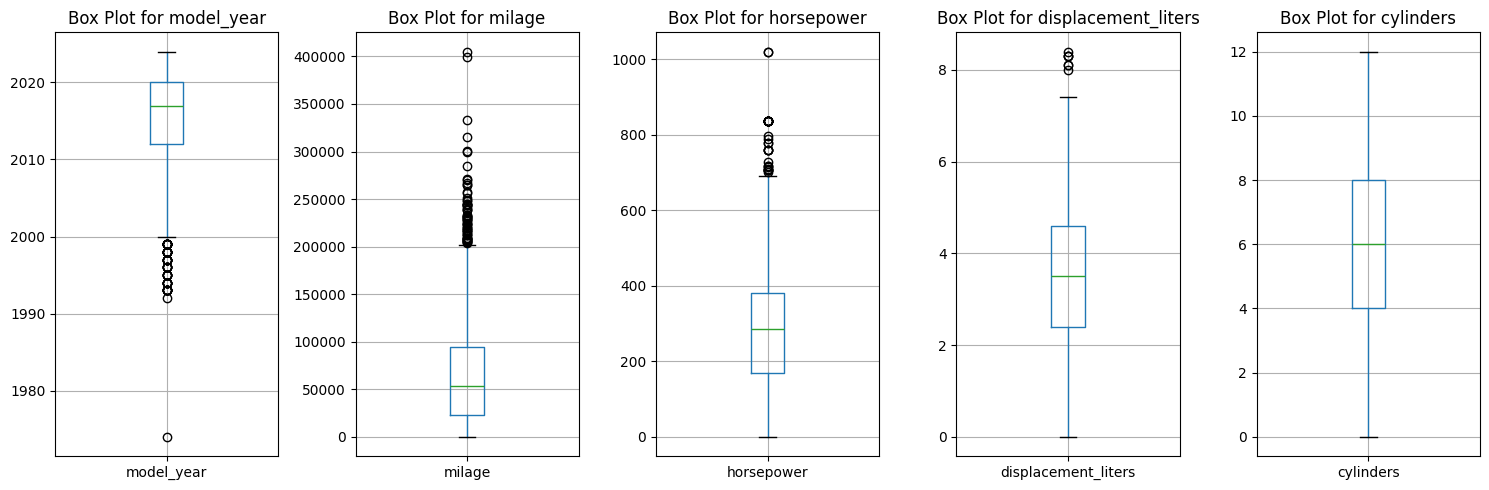

In [262]:
# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(df_numerical.columns) - 1, figsize=(15, 5))

# Loop through each column and create a box plot
for i, column in enumerate(df_numerical.drop(['price'], axis = 1).columns):
    df5.boxplot(column=column, ax=axes[i])
    axes[i].set_title(f'Box Plot for {column}')

plt.tight_layout()
plt.show()

This shows that there are outliers in model_year, milage, horsepower and didplacement liters. Let's try to handle these outliers.

In [263]:
columns = [
    'milage', 'model_year', 'horsepower', 'displacement_liters'
]

# Function to remove outliers using IQR method for each column separately
def remove_outliers_iqr(df):
    # Make a copy of the DataFrame to avoid modifying the original
    df_cleaned = df.copy()
    
    # Loop through each column
    for column in columns:
        # Calculate Q1, Q3, and IQR
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1
        
        # Calculate lower and upper bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Remove outliers in the current column
        df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]
    
    return df_cleaned

# Remove outliers column by column
df_cleaned = remove_outliers_iqr(df_numerical)
df_cleaned.head()


,model_year,milage,price,horsepower,displacement_liters,cylinders
0,2013,51000,10300,300.0,3.7,6
1,2021,34742,38005,0.0,3.8,6
2,2022,22372,54598,0.0,3.5,0
3,2015,88900,15500,354.0,3.5,6
4,2021,9835,34999,0.0,2.0,0


In [264]:
len(df_numerical), len(df_cleaned)

(3896, 3736)

Since, only 160 records are removed. This method is toally acceptable.

In [265]:
df5 = remove_outliers_iqr(df5)
df5.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,price,horsepower,displacement_liters,cylinders,engine_type
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,6-Speed A/T,Black,Black,At least 1 accident or damage reported,10300,300.0,3.7,6,V6
1,Hyundai,Palisade SEL,2021,34742,Gasoline,8-Speed Automatic,Others,Gray,At least 1 accident or damage reported,38005,0.0,3.8,6,V6
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Automatic,Blue,Black,None reported,54598,0.0,3.5,0,None
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,7-Speed A/T,Black,Black,None reported,15500,354.0,3.5,6,V6
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,8-Speed Automatic,Others,Black,None reported,34999,0.0,2.0,0,I4


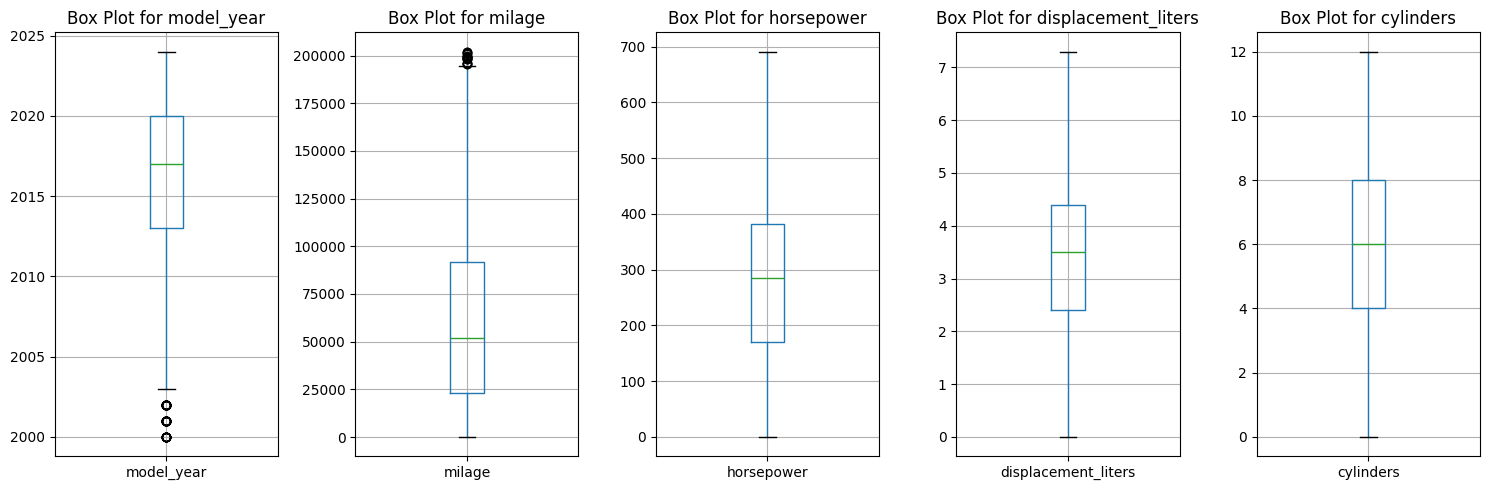

In [266]:
# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(df_numerical.columns) - 1, figsize=(15, 5))

# Loop through each column and create a box plot
for i, column in enumerate(df_numerical.drop(['price'], axis = 1).columns):
    df5.boxplot(column=column, ax=axes[i])
    axes[i].set_title(f'Box Plot for {column}')

plt.tight_layout()
plt.show()

Now, almost all the outliers are removed. Only, a few outliers have remained in such a narrow range that they can be neglected easily.

### Checking Co Relation

In [267]:
df_numerical.corr()

,model_year,milage,price,horsepower,displacement_liters,cylinders
model_year,1.000000,-0.625200,0.196643,-0.055169,-0.127002,-0.224172
milage,-0.625200,1.000000,-0.302596,0.000407,0.125025,0.183253
price,0.196643,-0.302596,1.000000,0.061781,0.128018,0.066950
horsepower,-0.055169,0.000407,0.061781,1.000000,0.330044,0.517075
displacement_liters,-0.127002,0.125025,0.128018,0.330044,1.000000,0.772342
cylinders,-0.224172,0.183253,0.066950,0.517075,0.772342,1.000000


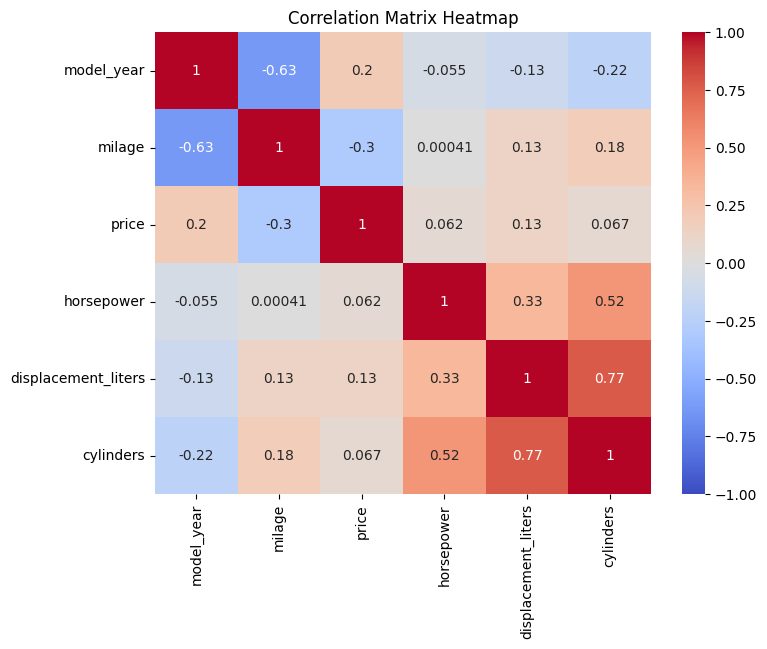

In [268]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

- Milage and Model Year have a negative co relation of 63%.
- Cylinders and liters of Displacement have a positove co relation of 77%.

In [269]:
# Compute the correlation of each column with the target column
correlations = df_numerical.corr()['price'].sort_values(ascending=False)

# Display the correlations
print(f"Correlations with Price \n{correlations}\n" )

Correlations with Price 
price                  1.000000
model_year             0.196643
displacement_liters    0.128018
cylinders              0.066950
horsepower             0.061781
milage                -0.302596
Name: price, dtype: float64



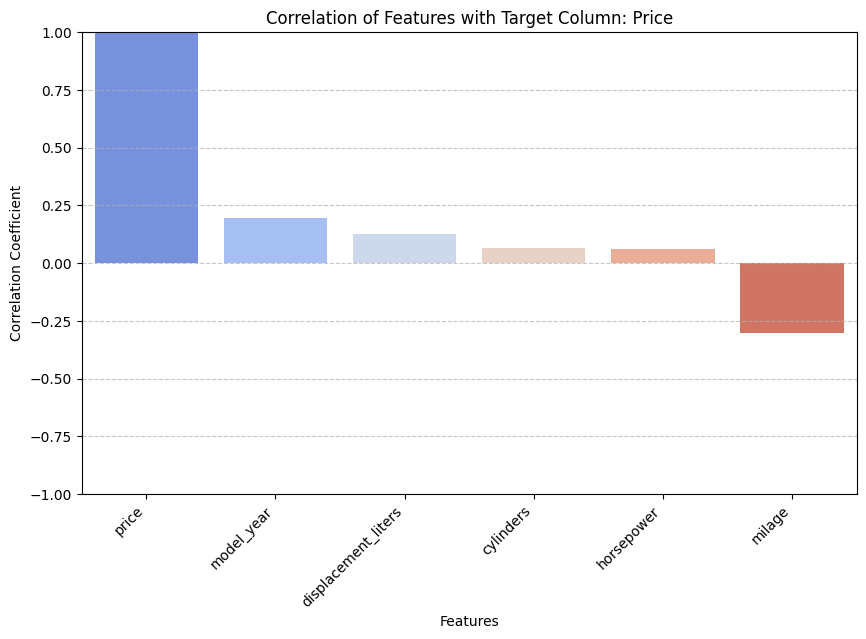

In [270]:
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.index, y=correlations.values, palette='coolwarm')

# Customize the plot
plt.title('Correlation of Features with Target Column: Price')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.ylim(-1, 1)  # Set y-axis limits to match correlation range
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for better readability

# Show the plot
plt.show()

This shows that each numerical column is certainly playing its part either in increasing or deceasing the Prizes.

- Milage is the only column that on increasing decreases the prize.

# Feature Encoding

Let's convert all the remaining Object columns to the numerical columns using Encoding Techniques. Here is what have to be done.

- **Brand** is encoded using Target encoding.
- **Model** is encoded using Target encoding.

The rest of the columns are encoded using one hot encoding.

In [342]:
df6 = df5.copy()

Since color does not impact much of the pricing hence droping the colors.

In [343]:
df6.drop(['ext_col', 'int_col'], axis=1, inplace=True)
df6.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'transmission',
       'accident', 'price', 'horsepower', 'displacement_liters', 'cylinders',
       'engine_type'],
      dtype='object')

In [350]:
Index = df6['model'].value_counts().index

with open("model_storevalues.txt", "w") as f:
    for i in Index:
        f.write(f"{str(i)}, ")

In [351]:
# Let's apply one hot encoding on the rest
columns_to_encode = ['brand','fuel_type', 'model', 'transmission', 'accident', 'engine_type']

In [352]:
df7 = df6.copy()
for col in columns_to_encode:
    # Apply one-hot encoding
    one_hot_encoded = pd.get_dummies(df7[col], drop_first=True)
    bool_df = one_hot_encoded.astype(int)
    
    # Drop original column and append the encoded columns
    df7 = df7.drop(col, axis=1)
    df7 = pd.concat([df7, bool_df], axis=1)
    
df7.head()

,model_year,milage,price,horsepower,displacement_liters,cylinders,Alfa,Aston,Audi,BMW,...,None,Turbo,V-10,V-12,V-6,V-8,V10,V12,V6,V8
0,2013,51000,10300,300.0,3.7,6,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,2021,34742,38005,0.0,3.8,6,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2022,22372,54598,0.0,3.5,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,2015,88900,15500,354.0,3.5,6,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,2021,9835,34999,0.0,2.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [353]:
df7.dtypes.values

array([dtype('int64'), dtype('int64'), dtype('int64'), ...,
       dtype('int64'), dtype('int64'), dtype('int64')], dtype=object)

In [354]:
df7.dtypes.index

Index(['model_year', 'milage', 'price', 'horsepower', 'displacement_liters',
       'cylinders', 'Alfa', 'Aston', 'Audi', 'BMW',
       ...
       'None', 'Turbo', 'V-10', 'V-12', 'V-6', 'V-8', 'V10', 'V12', 'V6',
       'V8'],
      dtype='object', length=1899)

Now, all of our values are converted and our dataframe is ready for model training.

Let's save our model first.

In [355]:
df7.to_csv("Cleaned_Prices.csv")

# Model Building

In [356]:
Cleaned_df = pd.read_csv("Cleaned_Prices.csv")

### Feature Scaling

In [357]:
columns_to_scale = ['model_year', 'milage', 'horsepower', 'displacement_liters',
       'cylinders']

In [358]:
# Separate the columns to scale and not to scale
df_to_scale = Cleaned_df[columns_to_scale]
df_not_to_scale = Cleaned_df.drop(columns=columns_to_scale)

# Apply the scaler to the selected columns
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_to_scale), columns=columns_to_scale)

# Step 4: Combine the scaled and unscaled dataframes
df_final = pd.concat([df_not_to_scale, df_scaled], axis=1)

df_final.head()

,Unnamed: 0,price,Alfa,Aston,Audi,BMW,Bentley,Buick,Cadillac,Chevrolet,...,V-8,V10,V12,V6,V8,model_year,milage,horsepower,displacement_liters,cylinders
0,0,10300,0,0,0,0,0,0,0,0,...,0,0,0,1,0,-0.539604,-0.236418,0.228452,0.150675,0.239722
1,1,38005,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0.926948,-0.581187,-1.588142,0.214085,0.239722
2,2,54598,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1.110267,-0.843506,-1.588142,0.023855,-1.969823
3,3,15500,0,0,0,0,0,0,0,0,...,0,0,0,1,0,-0.172966,0.567293,0.555439,0.023855,0.239722
4,4,34999,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0.926948,-1.109367,-1.588142,-0.927293,-1.969823


In [359]:
with open('Scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

### PCA

In [365]:
X = df_final.drop(['price','Unnamed: 0'], axis = 1)
y = df_final['price']

In [283]:
from sklearn.decomposition import PCA

# Initialize PCA, specifying the number of components to keep
pca = PCA()

# Fit PCA on the scaled data
X_pca = pca.fit_transform(X)

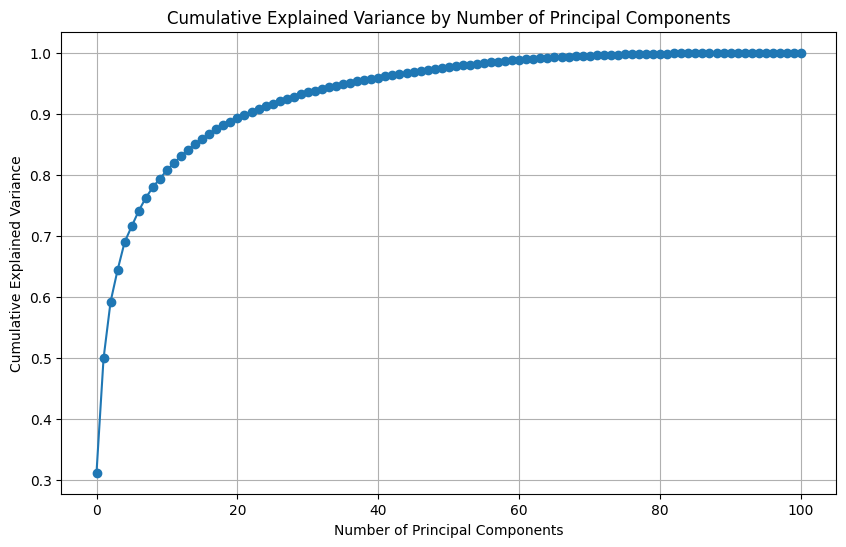

In [284]:
# Calculate cumulative explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance to visualize
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [285]:
# Determine number of components needed to retain 95% variance
desired_variance = 0.95
n_components_95 = np.argmax(cumulative_variance >= desired_variance) + 1
print(f"Number of components to retain 95% variance: {n_components_95}")

Number of components to retain 95% variance: 37


In [286]:
# Initialize PCA, specifying the number of components to keep
pca = PCA(n_components=37)

# Fit PCA on the scaled data
X_pca = pca.fit_transform(X)

### Train Test Split

In [366]:
len(X_pca[0])

37

In [367]:
# First split: training and temporary test (which will be further split)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# Second split: validation and test from the temporary test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Training features:\n", X_train.shape)
print("Validation features:\n", X_val.shape)
print("Testing features:\n", X_test.shape)

Training features:
 (2241, 1898)
Validation features:
 (747, 1898)
Testing features:
 (748, 1898)


### Model Building

#### Linear Regression

In [368]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Evaluate the model
print("Training performance:")
print("Mean Squared Error:", mean_squared_error(y_train, y_train_pred))
print("R^2 Score:", r2_score(y_train, y_train_pred))

print("\nValidation performance:")
print("Mean Squared Error:", mean_squared_error(y_val, y_val_pred))
print("R^2 Score:", r2_score(y_val, y_val_pred))

print("\nTest performance:")
print("Mean Squared Error:", mean_squared_error(y_test, y_test_pred))
print("R^2 Score:", r2_score(y_test, y_test_pred))

Training performance:
Mean Squared Error: 2032705700.9322846
R^2 Score: 0.6643433959373949

Validation performance:
Mean Squared Error: 5.970343900171676e+30
R^2 Score: -1.0388333335898118e+21

Test performance:
Mean Squared Error: 7.813572029384613e+30
R^2 Score: -3.1668977705072114e+21


#### Lasso

In [336]:
# Initialize the Lasso regression model with a regularization parameter (alpha)
lasso_model = Lasso(alpha=0.1)

# Fit the model to the training data
lasso_model.fit(X_train, y_train)

# Predict on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Calculate metrics
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression - Test MSE: {mse_lasso:.2f}, Test R^2 Score: {r2_lasso:.2f}")


Lasso Regression - Test MSE: 1189979545.43, Test R^2 Score: 0.52


#### Gradient Boosting Regressor

In [369]:
# Initialize the Gradient Boosting model with hyperparameters
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

# Fit the model to the training data
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)

# Calculate metrics
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting Regression - Test MSE: {mse_gb:.2f}, Test R^2 Score: {r2_gb:.2f}")


Gradient Boosting Regression - Test MSE: 470894430.07, Test R^2 Score: 0.81


In [370]:
# Predict on the Train set
y_pred_gb = gb_model.predict(X_train)

# Calculate metrics
mse_gb = mean_squared_error(y_train, y_pred_gb)
r2_gb = r2_score(y_train, y_pred_gb)

print(f"Gradient Boosting Regression - Train MSE: {mse_gb:.2f}, Test R^2 Score: {r2_gb:.2f}")

Gradient Boosting Regression - Train MSE: 119655147.49, Test R^2 Score: 0.98


In [371]:
# Predict on the Train set
y_pred_gb = gb_model.predict(X_train)

# Calculate metrics
mse_gb = mean_squared_error(y_train, y_pred_gb)
r2_gb = r2_score(y_train, y_pred_gb)

print(f"Gradient Boosting Regression - Validation MSE: {mse_gb:.2f}, Test R^2 Score: {r2_gb:.2f}")

Gradient Boosting Regression - Validation MSE: 119655147.49, Test R^2 Score: 0.98


**Gradient Boosting Regressor** worked fairly well wwith 98% score on both validation and train dataset and 81% score on Test Dataset.

#### Random Forest Regressor

In [340]:
# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor( random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate performance metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regression - Test Set")
print(f"Mean Squared Error: {mse_rf}")
print(f"R^2 Score: {r2_rf}")

Random Forest Regression - Test Set
Mean Squared Error: 554283009.8518862
R^2 Score: 0.775345050697867


In [333]:
# Predict on the train set
y_pred_rf = rf_model.predict(X_train)

# Calculate performance metrics
mse_rf = mean_squared_error(y_train, y_pred_rf)
r2_rf = r2_score(y_train, y_pred_rf)

print(f"Random Forest Regression - Train Set")
print(f"Mean Squared Error: {mse_rf}")
print(f"R^2 Score: {r2_rf}")

Random Forest Regression - Train Set
Mean Squared Error: 734974015.6587083
R^2 Score: 0.8786352190299307


**Random Forest Regressor** worked fairly well wwith 87% score on train dataset and 77% score on Test Dataset.

### Analysis

Since our primary goal is to maximize predictive accuracy, the Gradient Boosting Regressor is the better choice.

In [375]:
with open("GradientBoost.pkl", "wb") as f:
    pickle.dump(gb_model, f)

### Feature Importance Graph

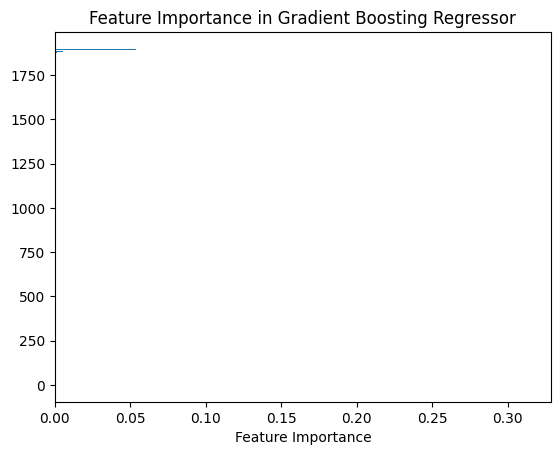

In [383]:
feature_names = X.columns[20]

feature_importance = gb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)

plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
# plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Gradient Boosting Regressor")
plt.show()

Out of all the features, omly a few one are playing their part.

### Learning Curve

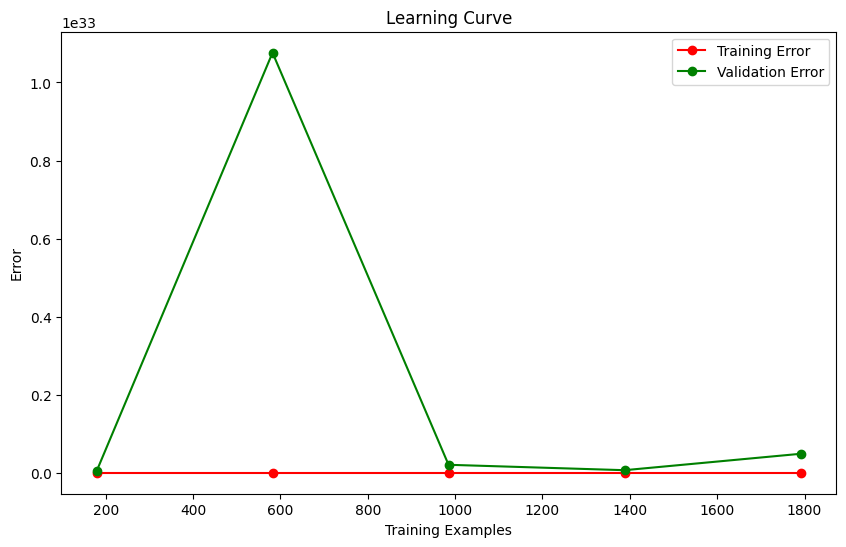

In [382]:
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Error')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Validation Error')
plt.xlabel("Training Examples")
plt.ylabel("Error")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.show()


This learning curve shos a significant decrease in training and validation error over the training.

### Residual Plot

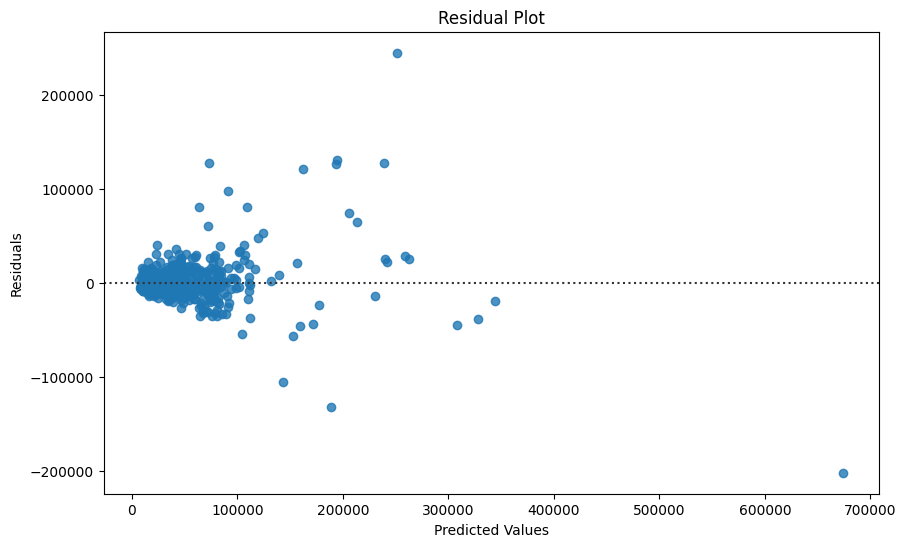

In [386]:
# Calculate predictions and residuals
y_pred = gb_model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, line_kws={'color': 'red', 'lw': 1})
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot suggests that the regression model is a reasonable fit for the data. However, the outliers are also present such as the one in lower right corer.

### Tree Visualization

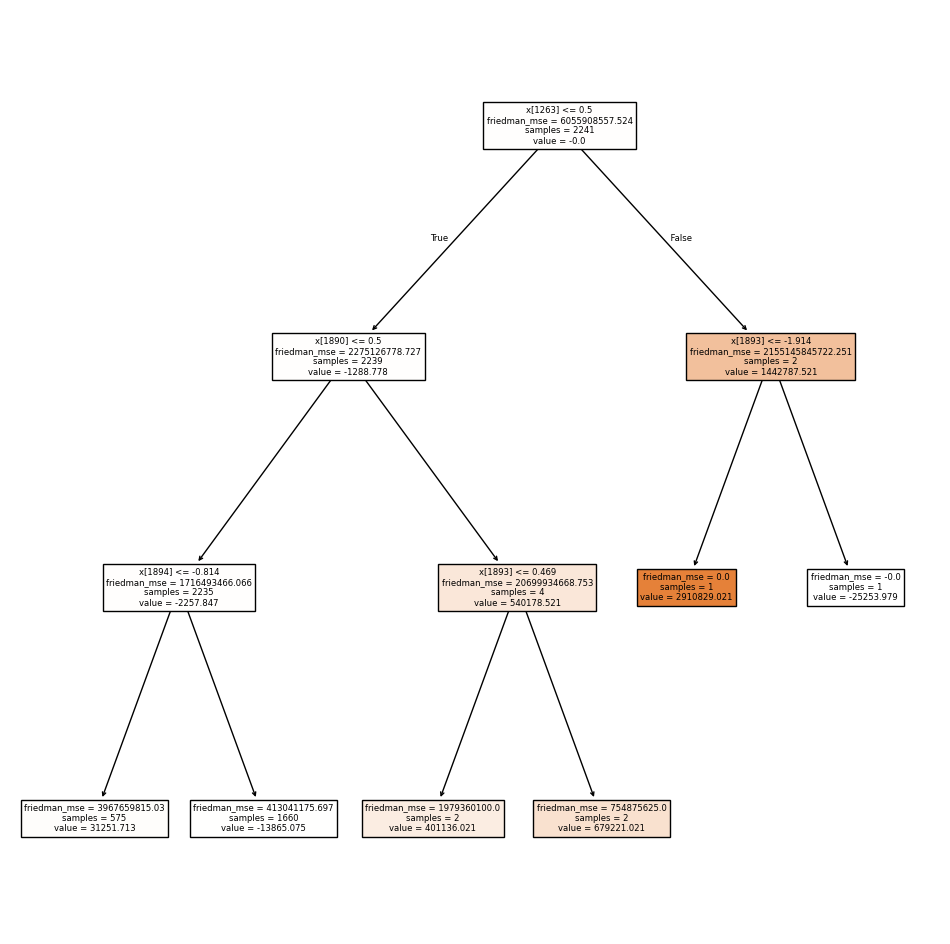

In [388]:
# Visualize a specific tree from the Gradient Boosting model
fig, ax = plt.subplots(figsize=(12, 12))
plot_tree(gb_model.estimators_[0, 0], ax=ax, filled=True)
plt.show()


This tree shows the work flow for the prediction. At some nodes, following featues are used X[1263], X[1890], X[1893], X[1894]. This explains the trends of the feature Importance Graph.

## Making Prediction

In [431]:
testing_dataset = pd.read_csv("Testing.csv")
with open('GradientBoost.pkl', 'rb') as file:
    model = pickle.load(file)
with open('Scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

In [432]:
columns = ['model_year',	'milage', 'horsepower', 'displacement_liters','cylinders']
array = []

for column in columns:
    array.append(float(testing_dataset[column]))

scaled_array = scaler.transform([array])
scaled_array

array([[ 0.74362946, -0.9998374 , -0.37707942, -0.92729329, -1.60156544]])

In [433]:
new_values = scaled_array[0]
for column in columns:
    testing_dataset[column] = new_values[0]

testing_dataset.head()

,Unnamed: 0,model_year,milage,horsepower,displacement_liters,cylinders,Alfa,Aston,Audi,BMW,...,None,Turbo,V-10,V-12,V-6,V-8,V10,V12,V6,V8
0,0,0.743629,0.743629,0.743629,0.743629,0.743629,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [435]:
testing_dataset = testing_dataset.drop(["Unnamed: 0"], axis = 1)

model.predict(testing_dataset.values)

array([107655.08710943])